In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("katehighnam/beth-dataset")

print("Path to dataset files:", path)

filelist = os.listdir(path)
print(len(filelist))
for entry in filelist:
    print(entry)

beth_testing_df = pd.read_csv(os.path.join(path, "labelled_testing_data.csv"))
beth_training_df = pd.read_csv(os.path.join(path, "labelled_training_data.csv"))
beth_validation_df = pd.read_csv(os.path.join(path, "labelled_validation_data.csv"))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/Farah.Ahmed/.cache/kagglehub/datasets/katehighnam/beth-dataset/versions/3
15
labelled_2021may-ip-10-100-1-4.csv
labelled_2021may-ubuntu-dns.csv
labelled_2021may-ubuntu.csv
labelled_2021may-ip-10-100-1-186-dns.csv
labelled_2021may-ip-10-100-1-4-dns.csv
labelled_2021may-ip-10-100-1-186.csv
labelled_training_data.csv
labelled_2021may-ip-10-100-1-95-dns.csv
labelled_2021may-ip-10-100-1-26.csv
labelled_2021may-ip-10-100-1-105-dns.csv
labelled_2021may-ip-10-100-1-95.csv
labelled_2021may-ip-10-100-1-26-dns.csv
labelled_testing_data.csv
labelled_validation_data.csv
labelled_2021may-ip-10-100-1-105.csv


In [2]:
numeric_cols = beth_training_df.select_dtypes(include='number').columns
target_cols = ['sus', 'evil']  

X_train = beth_training_df[numeric_cols].drop(columns=target_cols)
X_val = beth_validation_df[numeric_cols].drop(columns=target_cols)
X_test = beth_testing_df[numeric_cols].drop(columns=target_cols)

In [3]:
# Columns to drop
drop_cols = ['parentProcessId', 'threadId', 'processId', 'args', 'timestamp', 'evil']

# Drop columns from numeric features
X_train = X_train.drop(columns=[col for col in drop_cols if col in X_train.columns])
X_val = X_val.drop(columns=[col for col in drop_cols if col in X_val.columns])
X_test = X_test.drop(columns=[col for col in drop_cols if col in X_test.columns])


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Target column
y_train = beth_training_df['sus']
y_val = beth_validation_df['sus']
y_test = beth_testing_df['sus']

# Initialize Logistic Regression with class weighting
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Fit the model
logreg.fit(X_train_scaled, y_train)

# Predictions
y_val_pred = logreg.predict(X_val_scaled)
y_test_pred = logreg.predict(X_test_scaled)

# Evaluate performance
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))



Validation Accuracy: 0.9965232024639222
Test Accuracy: 0.9448686807749501

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.63      0.98      0.77     17508
           1       1.00      0.94      0.97    171459

    accuracy                           0.94    188967
   macro avg       0.81      0.96      0.87    188967
weighted avg       0.96      0.94      0.95    188967



Feature scaling and logistic regression applied

In [9]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, precision_recall_curve

# Get predicted probabilities for the positive class
y_test_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

# Explore thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_test_pred_thresh = (y_test_proba >= t).astype(int)
    f1 = f1_score(y_test, y_test_pred_thresh)
    print(f"Threshold: {t:.2f} → F1 Score: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

# Apply best threshold
y_test_pred_best = (y_test_proba >= best_threshold).astype(int)

# Evaluate with classification report
print("\nClassification Report (Test Set) with Best Threshold:")
print(classification_report(y_test, y_test_pred_best))

Threshold: 0.10 → F1 Score: 0.9521
Threshold: 0.15 → F1 Score: 0.9525
Threshold: 0.20 → F1 Score: 0.9615
Threshold: 0.25 → F1 Score: 0.9675
Threshold: 0.30 → F1 Score: 0.9687
Threshold: 0.35 → F1 Score: 0.9687
Threshold: 0.40 → F1 Score: 0.9687
Threshold: 0.45 → F1 Score: 0.9687
Threshold: 0.50 → F1 Score: 0.9687
Threshold: 0.55 → F1 Score: 0.9687
Threshold: 0.60 → F1 Score: 0.9687
Threshold: 0.65 → F1 Score: 0.9687
Threshold: 0.70 → F1 Score: 0.9689
Threshold: 0.75 → F1 Score: 0.9690
Threshold: 0.80 → F1 Score: 0.9691
Threshold: 0.85 → F1 Score: 0.9692
Threshold: 0.90 → F1 Score: 0.9692

Best Threshold: 0.9000000000000002
Best F1 Score: 0.9692020658140227

Classification Report (Test Set) with Best Threshold:
              precision    recall  f1-score   support

           0       0.63      0.99      0.77     17508
           1       1.00      0.94      0.97    171459

    accuracy                           0.95    188967
   macro avg       0.82      0.97      0.87    188967
weighted

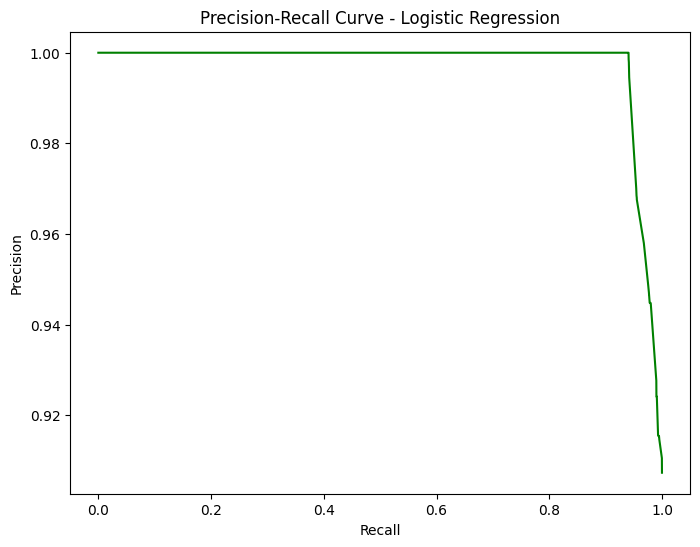

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()


In [11]:
%pip install fastparquet


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import kagglehub
import fastparquet

# Download latest version
path = kagglehub.dataset_download("dhoogla/unswnb15")

print("Path to dataset files:", path)

import os

print("Files:", os.listdir(path))

train_path = os.path.join(path, "UNSW_NB15_training-set.parquet")
test_path = os.path.join(path, "UNSW_NB15_testing-set.parquet")

train_unswnb15_df = pd.read_parquet(train_path, engine='fastparquet')
test_unswnb15_df = pd.read_parquet(test_path, engine='fastparquet')

Path to dataset files: /Users/Farah.Ahmed/.cache/kagglehub/datasets/dhoogla/unswnb15/versions/5
Files: ['UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']


In [13]:
train_unswnb15_clean_df = train_unswnb15_df.drop_duplicates().copy()
test_unswnb15_clean_df = test_unswnb15_df.drop_duplicates().copy()

print("Duplicate rows in cleaned train:", train_unswnb15_clean_df.duplicated().sum())
print("Duplicate rows in cleaned test:", test_unswnb15_clean_df.duplicated().sum())

categorical_columns = ['proto', 'service', 'state']
numeric_columns = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 
                   'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 
                   'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']

# Drop target columns from features
X = train_unswnb15_df.drop(columns=['label', 'attack_cat'])  
y = train_unswnb15_df['label']  

Duplicate rows in cleaned train: 0
Duplicate rows in cleaned test: 0


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_columns),
        ("num", StandardScaler(), numeric_columns)
    ]
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split training data into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create pipeline with preprocessing + logistic regression
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# Predict on validation set
y_val_pred = pipeline.predict(X_val)

# Evaluate
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.8887621546094842

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.80      0.87      0.83     11200
           1       0.93      0.90      0.92     23869

    accuracy                           0.89     35069
   macro avg       0.87      0.88      0.87     35069
weighted avg       0.89      0.89      0.89     35069



Feature scaling and logistic regression applied

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

#predicted probabilities for class 1
y_val_proba = pipeline.predict_proba(X_val)[:, 1]  # probability of class 1

#multiple thresholds to find the best F1 score
thresholds = np.arange(0.1, 0.91, 0.05)
best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_val_pred_thresh = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred_thresh)
    print(f"Threshold: {t:.2f} → F1 Score: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

# Apply the best threshold
y_val_pred_best = (y_val_proba >= best_threshold).astype(int)

# Evaluate with classification report
print("\nClassification Report (Validation Set) with Best Threshold:")
print(classification_report(y_val, y_val_pred_best))


Threshold: 0.10 → F1 Score: 0.9190
Threshold: 0.15 → F1 Score: 0.9247
Threshold: 0.20 → F1 Score: 0.9309
Threshold: 0.25 → F1 Score: 0.9353
Threshold: 0.30 → F1 Score: 0.9459
Threshold: 0.35 → F1 Score: 0.9443
Threshold: 0.40 → F1 Score: 0.9393
Threshold: 0.45 → F1 Score: 0.9291
Threshold: 0.50 → F1 Score: 0.9167
Threshold: 0.55 → F1 Score: 0.9052
Threshold: 0.60 → F1 Score: 0.8894
Threshold: 0.65 → F1 Score: 0.8721
Threshold: 0.70 → F1 Score: 0.8450
Threshold: 0.75 → F1 Score: 0.8000
Threshold: 0.80 → F1 Score: 0.7824
Threshold: 0.85 → F1 Score: 0.7676
Threshold: 0.90 → F1 Score: 0.7511

Best Threshold: 0.30000000000000004
Best F1 Score: 0.9458917031268815

Classification Report (Validation Set) with Best Threshold:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     11200
           1       0.91      0.99      0.95     23869

    accuracy                           0.92     35069
   macro avg       0.94      0.89      0.91     35069
w

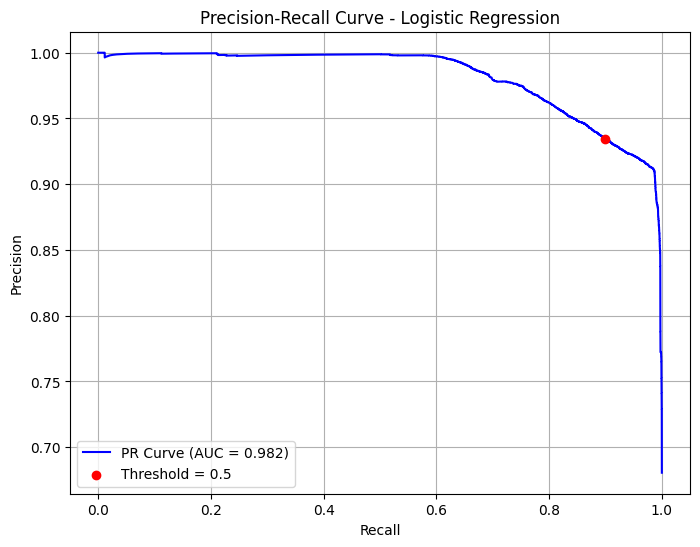

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Predicted probabilities for class 1
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='blue', label=f'PR Curve (AUC = {pr_auc:.3f})')

#mark optimal threshold
best_threshold = 0.5 
# Find closest threshold in array
closest_idx = np.argmin(np.abs(thresholds - best_threshold))
plt.scatter(recall[closest_idx], precision[closest_idx], color='red', label=f'Threshold = {best_threshold}', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()
